In [1]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import glob
from tqdm import tqdm

# ==========================================
# 1. DEFINE YOUR EXACT ARCHITECTURE
# ==========================================
class SafeFusionModule(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.noise_scale = nn.Parameter(torch.zeros(1, channels, 1, 1))
    
    def forward(self, x):
        noise = torch.randn(x.size(0), 1, x.size(2), x.size(3), device=x.device)
        return x + (noise * self.noise_scale)

class SketchGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features
        self.enc1 = nn.Sequential(*list(vgg.children())[:4])
        self.enc2 = nn.Sequential(*list(vgg.children())[4:14])
        self.enc3 = nn.Sequential(*list(vgg.children())[14:24])
        for p in self.parameters(): p.requires_grad = False
        self.fuse = SafeFusionModule(512)
        self.up1 = nn.Sequential(nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.InstanceNorm2d(256), nn.ReLU(True))
        self.up2 = nn.Sequential(nn.ConvTranspose2d(512, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.ReLU(True))
        self.up3 = nn.Sequential(nn.ConvTranspose2d(192, 64, 4, 2, 1), nn.InstanceNorm2d(64), nn.ReLU(True))
        self.final = nn.Conv2d(64, 1, 3, 1, 1)

    def forward(self, x):
        f1 = self.enc1(x)
        f2 = self.enc2(f1)
        f3 = self.enc3(f2)
        x = self.up1(self.fuse(f3))
        f2_rs = nn.functional.interpolate(f2, size=x.shape[2:]) if f2.shape[2:] != x.shape[2:] else f2
        x = self.up2(torch.cat([x, f2_rs], 1))
        f1_rs = nn.functional.interpolate(f1, size=x.shape[2:]) if f1.shape[2:] != x.shape[2:] else f1
        x = self.up3(torch.cat([x, f1_rs], 1))
        return torch.tanh(self.final(x))

# ==========================================
# 2. AUTO-LOAD YOUR KAGGLE MODEL
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Your specific Kaggle Model directory
model_dir = "/kaggle/input/models/ajay2606k/mymodel/pytorch/default/1"

# Auto-locate the .pth file inside that directory
pth_files = glob.glob(os.path.join(model_dir, "*.pth"))

if not pth_files:
    print(f"❌ ERROR: Could not find any .pth files inside {model_dir}")
    print("Please check if the model attached correctly in the right-hand panel.")
    raise SystemExit

model_path = pth_files[0]
print(f"Loading model weights from: {model_path}")

try:
    netG = SketchGenerator().to(device)
    checkpoint = torch.load(model_path, map_location=device)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        netG.load_state_dict(checkpoint['model_state_dict'])
    else:
        netG.load_state_dict(checkpoint)
    netG.eval()
    print(f"✅ Model loaded perfectly on {device}")
except Exception as e:
    print(f"❌ ERROR LOADING MODEL: {e}")
    raise SystemExit

# ==========================================
# 3. YOUR EXACT PROCESSING FUNCTION
# ==========================================
def create_enhanced_sketch(img_rgb):
    # STEP 1: CV2 Line Art
    img_np = np.array(img_rgb)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    gray = cv2.equalizeHist(gray)
    inverted = 255 - gray
    blur_kernel = 18
    k_size = (blur_kernel * 2) + 1
    blurred = cv2.GaussianBlur(inverted, (k_size, k_size), 0)
    sketch_cv2 = cv2.divide(gray, 255 - blurred, scale=256)
    
    kernel_sharpen = np.array([[-0.5, -0.5, -0.5],
                               [-0.5,  5.0, -0.5],
                               [-0.5, -0.5, -0.5]])
    sketch_cv2 = cv2.filter2D(sketch_cv2, -1, kernel_sharpen)
    sketch_cv2 = np.clip(sketch_cv2, 0, 255).astype(np.uint8)
    
    # STEP 2: AI Shading
    sketch_pil = Image.fromarray(sketch_cv2).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    input_tensor = transform(sketch_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        generated = netG(input_tensor)
        generated = generated.squeeze().cpu().detach().numpy()
        generated = (generated * 0.5 + 0.5) * 255.0
        generated = np.clip(generated, 0, 255).astype(np.uint8)
        
        if generated.shape != sketch_cv2.shape:
            generated = cv2.resize(generated, (sketch_cv2.shape[1], sketch_cv2.shape[0]), 
                                 interpolation=cv2.INTER_LANCZOS4)
    
    generated = cv2.convertScaleAbs(generated, alpha=1.15, beta=-10)
    
    # STEP 3: Blending (35% Strength)
    alpha = 0.35
    final_sketch = cv2.addWeighted(generated, alpha, sketch_cv2, 1 - alpha, 0)
    final_sketch = cv2.convertScaleAbs(final_sketch, alpha=1.05, beta=0)
    
    return final_sketch

# ==========================================
# 4. THE DATASET ENGINE
# ==========================================
def build_dataset():
    OUTPUT_DIR = "/kaggle/working/project_vibe_dataset"
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print("\n🔍 Scanning for CelebA images...")
    # This will find the images no matter where Kaggle mounted them
    all_images = glob.glob("/kaggle/input/**/*.jpg", recursive=True)
    
    if len(all_images) == 0:
        print("❌ ERROR: No CelebA images found! Click 'Add Data' on the right panel and add CelebA-HQ 256x256.")
        return
        
    print(f"✅ Found {len(all_images)} images! Queuing up 3,000 for GPU processing...")
    image_paths = all_images[:3000]

    for img_path in tqdm(image_paths, desc="Generating Vibe Sketches"):
        img_bgr = cv2.imread(img_path)
        if img_bgr is None: continue
            
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        # Run it through your pipeline!
        sketch_rgb = create_enhanced_sketch(img_rgb)
        
        filename = os.path.basename(img_path)
        save_path = os.path.join(OUTPUT_DIR, filename)
        
        sketch_bgr = cv2.cvtColor(sketch_rgb, cv2.COLOR_RGB2BGR)
        cv2.imwrite(save_path, sketch_bgr)

if __name__ == "__main__":
    build_dataset()
    print("\n🎉 Done! Run this in a new cell to zip it:")
    print("!zip -r dataset.zip /kaggle/working/project_vibe_dataset/")

Loading model weights from: /kaggle/input/models/ajay2606k/mymodel/pytorch/default/1/final_model_SHADING.pth
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 251MB/s]


✅ Model loaded perfectly on cuda

🔍 Scanning for CelebA images...
❌ ERROR: No CelebA images found! Click 'Add Data' on the right panel and add CelebA-HQ 256x256.

🎉 Done! Run this in a new cell to zip it:
!zip -r dataset.zip /kaggle/working/project_vibe_dataset/


In [2]:
!kaggle datasets download -d badasstechie/celebahq-resized-256x256 --unzip -p /kaggle/working/celeba_data

Dataset URL: https://www.kaggle.com/datasets/badasstechie/celebahq-resized-256x256
License(s): GPL-2.0
100%|████████████████████████████████████████| 283M/283M [00:09<00:00, 30.0MB/s]



In [3]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import glob
from tqdm import tqdm

# ==========================================
# 1. DEFINE YOUR EXACT ARCHITECTURE
# ==========================================
class SafeFusionModule(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.noise_scale = nn.Parameter(torch.zeros(1, channels, 1, 1))
    
    def forward(self, x):
        noise = torch.randn(x.size(0), 1, x.size(2), x.size(3), device=x.device)
        return x + (noise * self.noise_scale)

class SketchGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features
        self.enc1 = nn.Sequential(*list(vgg.children())[:4])
        self.enc2 = nn.Sequential(*list(vgg.children())[4:14])
        self.enc3 = nn.Sequential(*list(vgg.children())[14:24])
        for p in self.parameters(): p.requires_grad = False
        self.fuse = SafeFusionModule(512)
        self.up1 = nn.Sequential(nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.InstanceNorm2d(256), nn.ReLU(True))
        self.up2 = nn.Sequential(nn.ConvTranspose2d(512, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.ReLU(True))
        self.up3 = nn.Sequential(nn.ConvTranspose2d(192, 64, 4, 2, 1), nn.InstanceNorm2d(64), nn.ReLU(True))
        self.final = nn.Conv2d(64, 1, 3, 1, 1)

    def forward(self, x):
        f1 = self.enc1(x)
        f2 = self.enc2(f1)
        f3 = self.enc3(f2)
        x = self.up1(self.fuse(f3))
        f2_rs = nn.functional.interpolate(f2, size=x.shape[2:]) if f2.shape[2:] != x.shape[2:] else f2
        x = self.up2(torch.cat([x, f2_rs], 1))
        f1_rs = nn.functional.interpolate(f1, size=x.shape[2:]) if f1.shape[2:] != x.shape[2:] else f1
        x = self.up3(torch.cat([x, f1_rs], 1))
        return torch.tanh(self.final(x))

# ==========================================
# 2. AUTO-LOAD YOUR KAGGLE MODEL
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_dir = "/kaggle/input/models/ajay2606k/mymodel/pytorch/default/1"
pth_files = glob.glob(os.path.join(model_dir, "*.pth"))

if not pth_files:
    print(f"❌ ERROR: Could not find any .pth files inside {model_dir}")
    raise SystemExit

model_path = pth_files[0]
print(f"Loading model weights from: {model_path}")

try:
    netG = SketchGenerator().to(device)
    checkpoint = torch.load(model_path, map_location=device)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        netG.load_state_dict(checkpoint['model_state_dict'])
    else:
        netG.load_state_dict(checkpoint)
    netG.eval()
    print(f"✅ Model loaded perfectly on {device}")
except Exception as e:
    print(f"❌ ERROR LOADING MODEL: {e}")
    raise SystemExit

# ==========================================
# 3. YOUR EXACT PROCESSING FUNCTION
# ==========================================
def create_enhanced_sketch(img_rgb):
    # STEP 1: CV2 Line Art
    img_np = np.array(img_rgb)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    gray = cv2.equalizeHist(gray)
    inverted = 255 - gray
    blur_kernel = 18
    k_size = (blur_kernel * 2) + 1
    blurred = cv2.GaussianBlur(inverted, (k_size, k_size), 0)
    sketch_cv2 = cv2.divide(gray, 255 - blurred, scale=256)
    
    kernel_sharpen = np.array([[-0.5, -0.5, -0.5],
                               [-0.5,  5.0, -0.5],
                               [-0.5, -0.5, -0.5]])
    sketch_cv2 = cv2.filter2D(sketch_cv2, -1, kernel_sharpen)
    sketch_cv2 = np.clip(sketch_cv2, 0, 255).astype(np.uint8)
    
    # STEP 2: AI Shading
    sketch_pil = Image.fromarray(sketch_cv2).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    input_tensor = transform(sketch_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        generated = netG(input_tensor)
        generated = generated.squeeze().cpu().detach().numpy()
        generated = (generated * 0.5 + 0.5) * 255.0
        generated = np.clip(generated, 0, 255).astype(np.uint8)
        
        if generated.shape != sketch_cv2.shape:
            generated = cv2.resize(generated, (sketch_cv2.shape[1], sketch_cv2.shape[0]), 
                                 interpolation=cv2.INTER_LANCZOS4)
    
    generated = cv2.convertScaleAbs(generated, alpha=1.15, beta=-10)
    
    # STEP 3: Blending (35% Strength)
    alpha = 0.35
    final_sketch = cv2.addWeighted(generated, alpha, sketch_cv2, 1 - alpha, 0)
    final_sketch = cv2.convertScaleAbs(final_sketch, alpha=1.05, beta=0)
    
    return final_sketch

# ==========================================
# 4. THE DATASET ENGINE
# ==========================================
def build_dataset():
    OUTPUT_DIR = "/kaggle/working/project_vibe_dataset"
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print("\n🔍 Scanning for CelebA images...")
    all_images = glob.glob("/kaggle/working/celeba_data/**/*.jpg", recursive=True)
    
    if len(all_images) == 0:
        print("❌ ERROR: No images found! Did the !kaggle datasets download cell finish running?")
        return
        
    print(f"✅ Found {len(all_images)} images! Queuing up 3,000 for GPU processing...")
    image_paths = all_images[:3000]

    for img_path in tqdm(image_paths, desc="Generating Vibe Sketches"):
        img_bgr = cv2.imread(img_path)
        if img_bgr is None: continue
            
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        # Run it through your pipeline!
        sketch_rgb = create_enhanced_sketch(img_rgb)
        
        filename = os.path.basename(img_path)
        save_path = os.path.join(OUTPUT_DIR, filename)
        
        sketch_bgr = cv2.cvtColor(sketch_rgb, cv2.COLOR_RGB2BGR)
        cv2.imwrite(save_path, sketch_bgr)

if __name__ == "__main__":
    build_dataset()
    print("\n🎉 Done! Run this in a new cell to zip it:")
    print("!zip -r dataset.zip /kaggle/working/project_vibe_dataset/")

Loading model weights from: /kaggle/input/models/ajay2606k/mymodel/pytorch/default/1/final_model_SHADING.pth
✅ Model loaded perfectly on cuda

🔍 Scanning for CelebA images...
✅ Found 30000 images! Queuing up 3,000 for GPU processing...


Generating Vibe Sketches: 100%|██████████| 3000/3000 [00:45<00:00, 66.65it/s]


🎉 Done! Run this in a new cell to zip it:
!zip -r dataset.zip /kaggle/working/project_vibe_dataset/


In [4]:
!zip -r project_vibe_dataset.zip /kaggle/working/project_vibe_dataset/ > /dev/null
print("Dataset zipped and ready!")

Dataset zipped and ready!


In [5]:
import os
import glob
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

class PairedSketchDataset(Dataset):
    def __init__(self, original_dir, sketch_dir, transform=None):
        self.original_dir = original_dir
        self.sketch_dir = sketch_dir
        self.transform = transform
        
        # 1. Get the list of generated sketch filenames
        self.image_filenames = sorted(os.listdir(sketch_dir))
        
        # 2. THE FIX: Find the exact paths of the original images, ignoring subfolders
        all_orig_paths = glob.glob(f"{original_dir}/**/*.jpg", recursive=True)
        
        # Create a dictionary mapping the filename to its exact hidden path
        self.orig_path_map = {os.path.basename(p): p for p in all_orig_paths}

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        filename = self.image_filenames[idx]
        
        # 3. Use the dictionary to fetch the precise original path
        orig_path = self.orig_path_map[filename]
        sketch_path = os.path.join(self.sketch_dir, filename)
        
        orig_img = Image.open(orig_path).convert("RGB")
        sketch_img = Image.open(sketch_path).convert("RGB")
        
        if self.transform:
            orig_img = self.transform(orig_img)
            sketch_img = self.transform(sketch_img)
            
        return orig_img, sketch_img

# --- TEST THE DATALOADER ---
def test_loader():
    ORIG_DIR = "/kaggle/working/celeba_data"
    SKETCH_DIR = "/kaggle/working/project_vibe_dataset"
    
    # Standard GAN transforms: Resize to 256x256, convert to Tensor, normalize to [-1, 1]
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    dataset = PairedSketchDataset(ORIG_DIR, SKETCH_DIR, transform=transform)
    dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
    
    print(f"✅ Paired Dataset created successfully with {len(dataset)} image pairs!")
    
    # Grab one batch to verify
    orig_batch, sketch_batch = next(iter(dataloader))
    print(f"✅ Original Batch shape: {orig_batch.shape}")
    print(f"✅ Sketch Batch shape:   {sketch_batch.shape}")

if __name__ == "__main__":
    test_loader()

✅ Paired Dataset created successfully with 3000 image pairs!
✅ Original Batch shape: torch.Size([4, 3, 256, 256])
✅ Sketch Batch shape:   torch.Size([4, 3, 256, 256])


In [6]:
import torch
import torch.nn as nn

# ==========================================
# 1. THE U-NET GENERATOR
# ==========================================
class UNetDown(nn.Module):
    def __init__(self, in_size, out_size, normalize=True, dropout=0.0):
        super().__init__()
        layers = [nn.Conv2d(in_size, out_size, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.InstanceNorm2d(out_size))
        layers.append(nn.LeakyReLU(0.2))
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

class UNetUp(nn.Module):
    def __init__(self, in_size, out_size, dropout=0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_size, out_size, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(out_size),
            nn.ReLU(inplace=True)
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip_input):
        x = self.model(x)
        x = torch.cat((x, skip_input), 1)
        return x

class GeneratorUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()
        self.down1 = UNetDown(in_channels, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512, dropout=0.5)
        self.down5 = UNetDown(512, 512, dropout=0.5)
        self.down6 = UNetDown(512, 512, dropout=0.5)
        self.down7 = UNetDown(512, 512, dropout=0.5)
        self.down8 = UNetDown(512, 512, normalize=False, dropout=0.5)

        self.up1 = UNetUp(512, 512, dropout=0.5)
        self.up2 = UNetUp(1024, 512, dropout=0.5)
        self.up3 = UNetUp(1024, 512, dropout=0.5)
        self.up4 = UNetUp(1024, 512, dropout=0.5)
        self.up5 = UNetUp(1024, 256)
        self.up6 = UNetUp(512, 128)
        self.up7 = UNetUp(256, 64)

        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(128, out_channels, 4, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        d8 = self.down8(d7)
        u1 = self.up1(d8, d7)
        u2 = self.up2(u1, d6)
        u3 = self.up3(u2, d5)
        u4 = self.up4(u3, d4)
        u5 = self.up5(u4, d3)
        u6 = self.up6(u5, d2)
        u7 = self.up7(u6, d1)
        return self.final(u7)

# ==========================================
# 2. THE PATCH-GAN DISCRIMINATOR
# ==========================================
class Discriminator(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        def discriminator_block(in_filters, out_filters, normalization=True):
            layers = [nn.Conv2d(in_filters, out_filters, 4, stride=2, padding=1)]
            if normalization:
                layers.append(nn.InstanceNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *discriminator_block(in_channels * 2, 64, normalization=False), # Looks at Photo + Sketch stacked
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, 4, padding=1, bias=False)
        )

    def forward(self, img_A, img_B):
        # Concatenate image and condition image by channels to produce input
        img_input = torch.cat((img_A, img_B), 1)
        return self.model(img_input)

# ==========================================
# 3. INITIALIZE AND SEND TO GPU
# ==========================================
def init_weights(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        torch.nn.init.normal_(m.weight.data, 0.0, 0.02)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = GeneratorUNet().to(device)
discriminator = Discriminator().to(device)

# Apply standard GAN weight initialization
generator.apply(init_weights)
discriminator.apply(init_weights)

print(f"✅ U-Net Generator loaded on {device}")
print(f"✅ PatchGAN Discriminator loaded on {device}")

✅ U-Net Generator loaded on cuda
✅ PatchGAN Discriminator loaded on cuda


In [7]:
import torch.optim as optim
from tqdm import tqdm
import os

# ==========================================
# 1. OPTIMIZERS & LOSS FUNCTIONS
# ==========================================
# PatchGAN uses Mean Squared Error for adversarial loss
criterion_GAN = nn.MSELoss() 
# L1 Loss prevents the sketches from becoming blurry
criterion_pixelwise = nn.L1Loss() 

# Standard Pix2Pix learning rates
lr = 0.0002
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

# We weight the pixel loss 100x higher so it prioritizes your exact line-art style
lambda_pixel = 100 

# ==========================================
# 2. THE TRAINING ENGINE
# ==========================================
def train_project_vibe(epochs=5):
    print(f"🚀 Igniting Project Vibe Training for {epochs} Epochs...")
    
    # Re-instantiate the dataloader from earlier
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    dataset = PairedSketchDataset("/kaggle/working/celeba_data", "/kaggle/working/project_vibe_dataset", transform=transform)
    # Pushing batch_size to 16 to utilize the Kaggle GPU
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2)
    
    for epoch in range(epochs):
        loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for i, (real_A, real_B) in enumerate(loop):
            # Move images to the GPU
            real_A = real_A.to(device)
            real_B = real_B.to(device)
            
            # ------------------
            #  Train Generator
            # ------------------
            optimizer_G.zero_grad()
            
            # Generate a fake sketch from the real photo
            fake_B = generator(real_A)
            
            # Ask Discriminator to judge the fake sketch
            pred_fake = discriminator(fake_B, real_A)
            
            # Adversarial ground truths (dynamic sizing so it never crashes)
            valid = torch.ones_like(pred_fake, device=device, requires_grad=False)
            fake = torch.zeros_like(pred_fake, device=device, requires_grad=False)
            
            # Generator wants the discriminator to think the fake is valid (1)
            loss_GAN = criterion_GAN(pred_fake, valid)
            
            # Pixel-wise loss: How close is the fake sketch to your proprietary sketch?
            loss_pixel = criterion_pixelwise(fake_B, real_B)
            
            # Total Generator loss
            loss_G = loss_GAN + lambda_pixel * loss_pixel
            
            loss_G.backward()
            optimizer_G.step()

            # ---------------------
            #  Train Discriminator
            # ---------------------
            optimizer_D.zero_grad()
            
            # Real Loss: Discriminator should rate the real sketch as valid (1)
            pred_real = discriminator(real_B, real_A)
            loss_real = criterion_GAN(pred_real, valid)
            
            # Fake Loss: Discriminator should rate the generated sketch as fake (0)
            # We use .detach() so we don't accidentally update the generator's weights here
            pred_fake = discriminator(fake_B.detach(), real_A)
            loss_fake = criterion_GAN(pred_fake, fake)
            
            # Total Discriminator loss
            loss_D = 0.5 * (loss_real + loss_fake)
            
            loss_D.backward()
            optimizer_D.step()
            
            # Update the progress bar with live metrics
            loop.set_postfix(D_loss=loss_D.item(), G_loss=loss_G.item())
            
    # Save the newly trained model weights
    os.makedirs("/kaggle/working/saved_models", exist_ok=True)
    save_path = "/kaggle/working/saved_models/project_vibe_generator_v1.pth"
    torch.save(generator.state_dict(), save_path)
    
    print(f"\n🎉 Training Complete! Your new model is saved at: {save_path}")

if __name__ == "__main__":
    # We start with 5 epochs to verify it runs flawlessly
    train_project_vibe(epochs=5)

🚀 Igniting Project Vibe Training for 5 Epochs...


Epoch 5/5: 100%|██████████| 188/188 [00:53<00:00,  3.53it/s, D_loss=0.103, G_loss=8.15]



🎉 Training Complete! Your new model is saved at: /kaggle/working/saved_models/project_vibe_generator_v1.pth


Loading your newly trained Project Vibe weights...


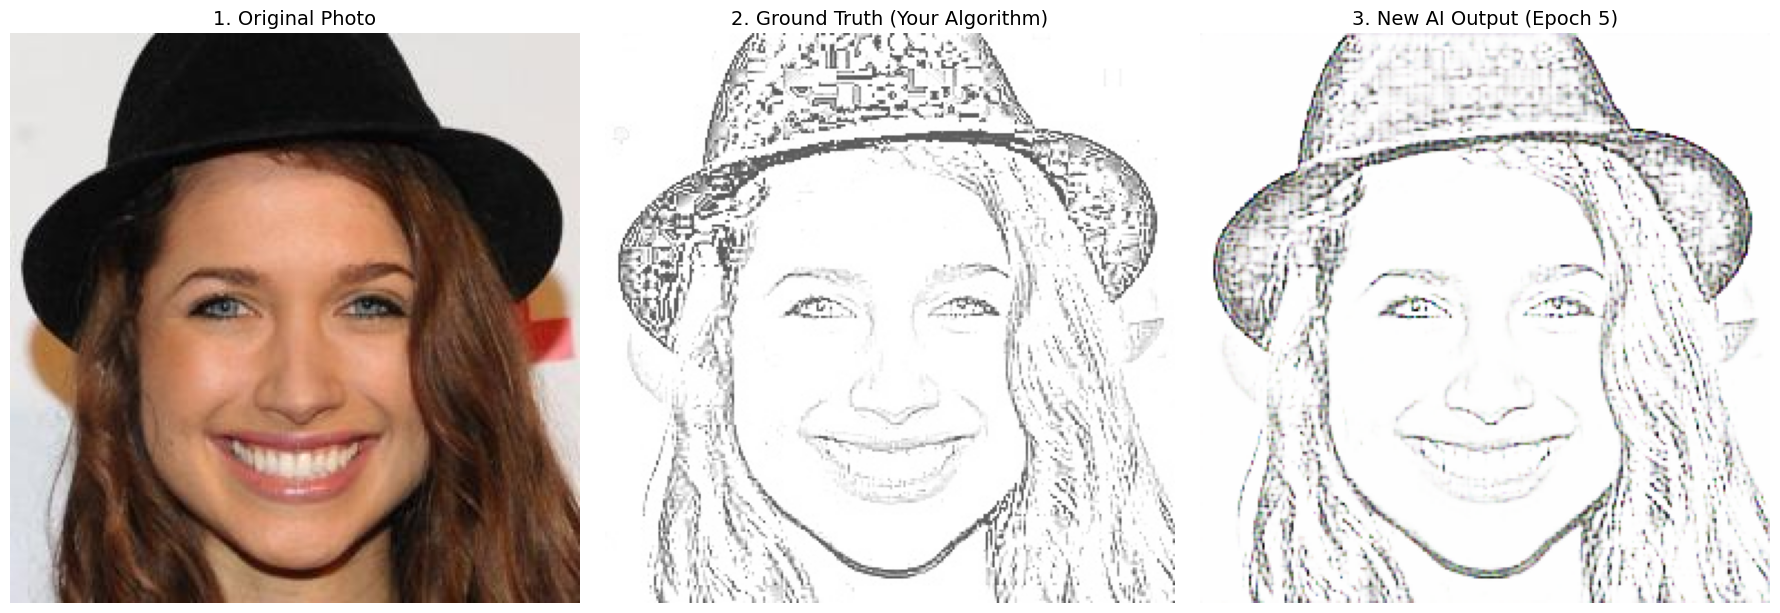

In [8]:
import os
import glob
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

def visualize_new_model():
    print("Loading your newly trained Project Vibe weights...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Initialize the generator and load your 5-epoch weights
    model = GeneratorUNet().to(device)
    model.load_state_dict(torch.load("/kaggle/working/saved_models/project_vibe_generator_v1.pth"))
    model.eval()

    # THE FIX: Pick a random image from your proprietary dataset of 3,000
    sketch_dir = "/kaggle/working/project_vibe_dataset"
    sketch_files = os.listdir(sketch_dir)
    filename = random.choice(sketch_files)
    
    target_path = os.path.join(sketch_dir, filename)
    
    # Find the exact matching original photo in the CelebA folder
    orig_search = glob.glob(f"/kaggle/working/celeba_data/**/{filename}", recursive=True)
    orig_path = orig_search[0]
    
    # Load original photo and your ground truth sketch
    orig_img = Image.open(orig_path).convert("RGB")
    target_img = Image.open(target_path).convert("RGB")
    
    # Transform for the neural network
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    input_tensor = transform(orig_img).unsqueeze(0).to(device)
    
    # Generate the new sketch!
    with torch.no_grad():
        generated = model(input_tensor)
        
    # Denormalize the tensor back into a standard viewable image
    def denorm(tensor):
        img = tensor.squeeze().cpu().numpy()
        img = (img * 0.5 + 0.5) * 255
        return np.clip(img, 0, 255).astype(np.uint8).transpose(1, 2, 0)
        
    gen_img = denorm(generated)
    
    # Plot the results side-by-side
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    
    axs[0].imshow(orig_img.resize((256,256)))
    axs[0].set_title("1. Original Photo", fontsize=14)
    axs[0].axis('off')
    
    axs[1].imshow(target_img.resize((256,256)))
    axs[1].set_title("2. Ground Truth (Your Algorithm)", fontsize=14)
    axs[1].axis('off')
    
    axs[2].imshow(gen_img)
    axs[2].set_title("3. New AI Output (Epoch 5)", fontsize=14)
    axs[2].axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_new_model()

--------------------training completed day 01 ---------- Sleep time -------------

In [9]:
import os
import shutil
import glob

# 1. Define paths for the Master Package
BASE_DIR = "/kaggle/working/project_vibe_master_package"
ORIG_OUT = os.path.join(BASE_DIR, "originals")
SKETCH_OUT = os.path.join(BASE_DIR, "sketches")
MODEL_OUT = os.path.join(BASE_DIR, "baby_model")

# 2. Create the folder structure
if os.path.exists(BASE_DIR): shutil.rmtree(BASE_DIR)
os.makedirs(ORIG_OUT, exist_ok=True)
os.makedirs(SKETCH_OUT, exist_ok=True)
os.makedirs(MODEL_OUT, exist_ok=True)

# 3. Copy the Baby Model (v1.pth)
# We look in the saved_models folder we created during training
model_src = "/kaggle/working/saved_models/project_vibe_generator_v1.pth"
if os.path.exists(model_src):
    shutil.copy(model_src, os.path.join(MODEL_OUT, "project_vibe_generator_v1.pth"))
    print("✅ Baby Model (v1.pth) added to package.")

# 4. Copy the Image Pairs (3,000 pairs)
sketch_files = os.listdir("/kaggle/working/project_vibe_dataset")
print(f"📦 Packaging {len(sketch_files)} image pairs...")

for filename in sketch_files:
    # Copy generated sketch
    shutil.copy(f"/kaggle/working/project_vibe_dataset/{filename}", os.path.join(SKETCH_OUT, filename))
    
    # Find and copy matching CelebA original
    orig_search = glob.glob(f"/kaggle/working/celeba_data/**/{filename}", recursive=True)
    if orig_search:
        shutil.copy(orig_search[0], os.path.join(ORIG_OUT, filename))

# 5. Create the Master ZIP
shutil.make_archive("/kaggle/working/project_vibe_FINAL_BACKUP", 'zip', BASE_DIR)
print("\n🚀 SUCCESS! Download 'project_vibe_FINAL_BACKUP.zip' from the right panel.")
print("This zip contains your dataset folders and your trained baby model.")

✅ Baby Model (v1.pth) added to package.
📦 Packaging 3000 image pairs...

🚀 SUCCESS! Download 'project_vibe_FINAL_BACKUP.zip' from the right panel.
This zip contains your dataset folders and your trained baby model.
